## Importación

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

## Parámetros de la distribución t
El parámetro fundamental de la distribución t es:

* ```df``` → grados de libertad

También existen:

* ```loc``` → ubicación
* ```scale``` → escala

In [2]:
df = 10
loc = 0
scale = 1

En la distribución t estándar:

* ```loc = 0```
* ```scale = 1```

In [3]:
dist = t(df=df, loc=loc, scale=scale)

## Visualizar la distribución t

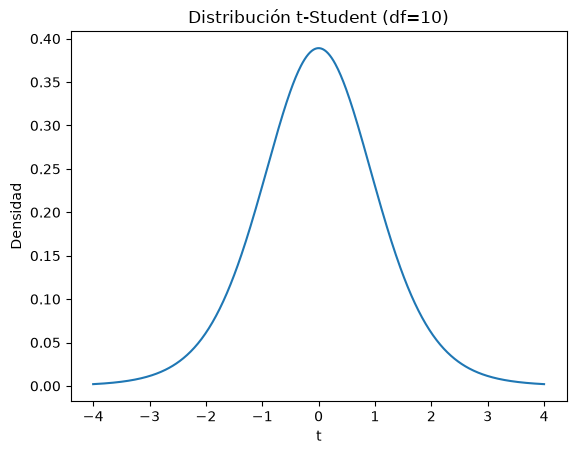

In [4]:
x = np.linspace(-4, 4, 500)

pdf = t.pdf(x, df=df, loc=loc, scale=scale)
plt.plot(x, pdf)
plt.xlabel("t")
plt.ylabel("Densidad")
plt.title(f"Distribución t-Student (df={df})")
plt.show()

Se observa que la distribución es simétrica alrededor de 0, pero tiene colas más pesadas que la normal estándar.

## PDF - función de densidad
```pdf()``` responde:
- ¿Cuál es la densidad de la distribución en un determinado valor de ```t```?

In [5]:
t_value = 2

density = t.pdf(t_value, df=df)

print(density)

0.061145766321218174


## CDF - probabilidad acumulada

```cdf()``` responde:

¿Cuál es la probabilidad de obtener un valor menor o igual a ```t```?

Por ejemplo:

In [6]:
t_value = 2

p = t.cdf(t_value, df=df)

print(p)

0.9633059826146299


Esto calcula:

$$ P(T \leq 2) $$

donde:

$$ T \sim t(df=10) $$

### Probabilidad de obtener un valor mayor que ```t```

In [8]:
t_value = 2

p_right = 1 - t.cdf(t_value, df=df)

print(p_right)

0.03669401738537015


Esto responde:

$$ P(T > 2) $$

### Probabilidad entre dos valores
Por ejemplo:

¿Cuál es la probabilidad de que T esté entre -2 y 2?

In [9]:
p = t.cdf(2, df=df) - t.cdf(-2, df=df)

print(p)

0.9266119652292597


Responde a:

$$ P(-2 \leq T \leq 2) $$

## PPF — obtener el valor t crítico
```ppf()``` recibe una probabilidad y devuelve el valor de t correspondiente.

Por ejemplo:

In [10]:
probabilidad = 0.975

t_critical = t.ppf(probabilidad, df=df)

print(t_critical)

2.228138851986274


Esto responde:

¿Qué valor de t deja 97.5 % del área a la izquierda?

Es decir:

$$ P(T \leq t_{crítico})=0.975 $$

Valor crítico para una prueba bilateral

In [11]:
alpha = 0.05

t_critical = t.ppf(1 - alpha/2, df=df)

print(t_critical)

2.228138851986274


Los valores críticos serían:

$$ -2.228 \quad \text{y} \quad 2.228 $$

La región de rechazo sería:

$$ t < -2.228 $$

o

$$ t > 2.228 $$

## Relación entre CDF y PPF

In [12]:
probabilidad = 0.975

t_value = t.ppf(probabilidad, df=10)

probabilidad_resultado = t.cdf(t_value, df=10)

print(t_value)
print(probabilidad_resultado)

2.228138851986274
0.975


Conceptualmente:

PPF

```probabilidad ─────────► valor t```


CDF

```valor t ───────────────► probabilidad```

Por ejemplo:

$$ PPF(0.975)=2.228 $$

y luego:

$$ CDF(2.228)\approx0.975 $$

## t calculado / estadístico t

Para una prueba t de una muestra, el estadístico se calcula como:

$$ t=\frac{\bar{x}-\mu_0}{s/\sqrt{n}} $$

In [13]:
sample_mean = 105
population_mean = 100
sample_std = 15
n = 25

t_calculated = (sample_mean - population_mean) / (sample_std / np.sqrt(n))

print(t_calculated)

1.6666666666666667


### Comparar t calculado y t crítico

In [14]:
alpha = 0.05
df = n - 1

t_critical = t.ppf(1 - alpha / 2, df=df)

print("t calculado:", t_calculated)
print("t crítico:", t_critical)

t calculado: 1.6666666666666667
t crítico: 2.0638985616280245


Conceptualmente:

$$ - t_{crítico} < t_{calculado} < t_{crítico} $$

Como:

$$ |t_{calculado}| < t_{crítico} $$

no se encuentra en la región de rechazo.

## Comparación de diferentes grados de libertad

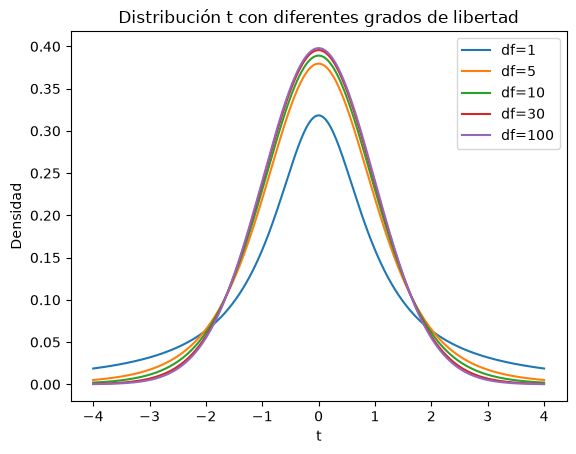

In [16]:
x = np.linspace(-4, 4, 500)

for df in [1, 5, 10, 30, 100]:
    plt.plot(x, t.pdf(x, df=df), label=f"df={df}")

plt.xlabel("t")
plt.ylabel("Densidad")
plt.title("Distribución t con diferentes grados de libertad")
plt.legend()
plt.show()

Se logra observar que:

$$ df \uparrow \quad\Rightarrow\quad t \rightarrow N(0,1) $$

Es decir, a medida que aumentan los grados de libertad, la distribución t se aproxima a la normal estándar.